<table style="width:100%">
  <tr>
    <td valign="top"><img src="../data/img/FER_logo_2.png" width=300 height=80 align="left"></td>
    <td valign="top"><img src="../data/img/LARES_2_transparent.png" width=250 height=80 align="right"></td>
  </tr>
 </table>

# Regression - House prices

![housing](../data/img/house-prices.jpg)

## Import modules

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

In [2]:
from scipy.stats import skew
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": False,
    "font.family": "serif",
    # Use 26pt font in plots
    "axes.labelsize": 16,
    "font.size": 16,
    "figure.titlesize": 16,
    # Make the legend/label fonts a little smaller
    "legend.title_fontsize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
}

plt.rcParams.update(tex_fonts)

%matplotlib inline
inline_rc = dict(matplotlib.rcParams)
# %matplotlib notebook
%config InlineBackend.figure_format='svg'
plt.rcParams['figure.figsize'] = (10, 6)

sns.set(style="whitegrid", color_codes=True)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from matplotlib.axes._axes import _log as matplotlib_axes_logger
matplotlib_axes_logger.setLevel('ERROR')

## Supervised learning for regression
0. Preprocess data

1. Create/build model

2. Tune model

3. Evaluate model

4. Hands on

## 0. (Pre)process data

In [4]:
X_train = pd.read_csv("../data/housing_prices/X_train.csv", index_col='Id')
y_train = pd.read_csv("../data/housing_prices/y_train.csv", index_col='Id')
X_test = pd.read_csv("../data/housing_prices/X_test.csv", index_col='Id')
y_test = pd.read_csv("../data/housing_prices/y_test.csv", index_col='Id')

### Transform the skewed numeric features - normalization

Make copies of the data to show the difference between the data predictions from the data with and without skew correction:

#### Normalizing the data

In [5]:
# log transform the target:
y_train_normal = y_train.copy()
y_train_normal["SalePrice"] = np.log1p(y_train_normal["SalePrice"])

In [6]:
X_test.columns

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
       '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd'],
      dtype='object')

In [7]:
# log transform skewed numeric features:
all_data_normal = pd.concat([X_train, X_test])
numeric_feats = all_data_normal.dtypes[all_data_normal.dtypes != "object"].index

skewed_feats = all_data_normal[numeric_feats].apply(lambda x: skew(x.dropna())) # compute skewness
skewed_feats = skewed_feats[skewed_feats > 0.75]
skewed_feats = skewed_feats.index

all_data_normal[skewed_feats] = np.log1p(all_data_normal[skewed_feats])

In [8]:
all_data_normal

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd
Id,,,,,,,,,,
758,6,7.234898,2,440,6.511745,6.511745,2,6,1978,1978
599,5,7.407318,2,621,7.266129,7.407318,2,7,1977,1977
216,5,7.120444,1,447,6.976348,7.120444,1,6,1957,1996
136,7,7.428333,2,530,7.173958,7.428333,2,7,1970,1970
373,6,6.624065,1,264,6.613384,6.624065,1,4,1984,1984
...,...,...,...,...,...,...,...,...,...,...
281,7,7.592366,2,575,6.694562,7.069874,2,7,1989,1989
1402,6,7.374002,2,398,6.733402,6.762730,2,8,2004,2004
132,6,7.628031,2,390,6.900731,6.930495,2,7,2000,2000


In [9]:
# Create matrices for sklearn:
X_train_normal = all_data_normal.loc[X_train.index, :]
X_test_normal = all_data_normal.loc[X_test.index, :]

# Models

## Linear Regression - the 'by-hand' way

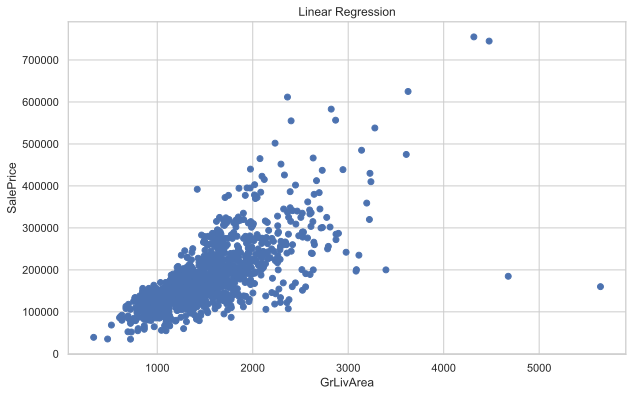

In [10]:
# create a figure
fig = plt.figure()
# get the axis of that figure
ax = plt.gca()

# plot the data
ax.scatter(X_train['GrLivArea'].values, y_train['SalePrice'].values, color ='b');
plt.title("Linear Regression")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice");

\begin{equation*}
\Large{y=mX+b}\\
\Large{y = \beta_0 + \beta_1 x + \epsilon}
\end{equation*}

## 1. Create/Build model

In [11]:
train = X_train.copy()
train['SalePrice'] = y_train['SalePrice'].values

## Calculating the beta coefficients by hand. 
## mean of y. 
y_bar = train['SalePrice'].mean()
## mean of x. 
x_bar = train['GrLivArea'].mean()
## Std of y
std_y = train['SalePrice'].std()
## std of x
std_x = train['GrLivArea'].std()
## correlation of x and y
r_xy = train.corr().loc['GrLivArea','SalePrice']

## 2. Fit model

In [12]:
## finding beta_1
beta_1 = r_xy*(std_y/std_x)
## finding beta_0
beta_0 = y_bar - beta_1*x_bar

## 3. Evaluate the model

In [13]:
linear = beta_0 + beta_1*X_train['GrLivArea']

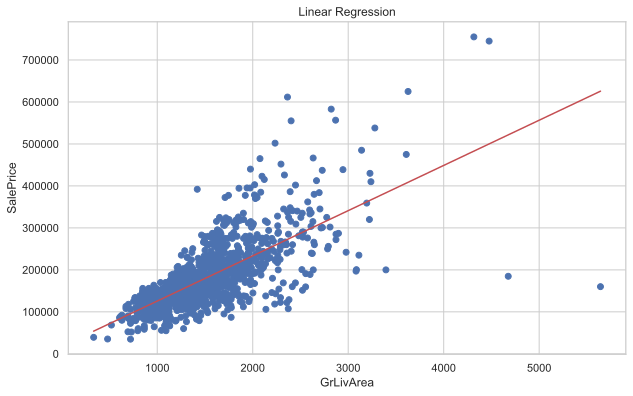

In [14]:
# create a figure
fig = plt.figure()
# get the axis of that figure
ax = plt.gca()

# plot a scatter plot on it with our data
ax.scatter(train.GrLivArea, train.SalePrice, c='b')
ax.plot(train['GrLivArea'], linear, color='r');
plt.title("Linear Regression")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice");

# Linear regression - scikit-learn way

In [15]:
lr = LinearRegression()
lr.fit(X_train['GrLivArea'].values.reshape(-1, 1),y_train['SalePrice'].values.reshape(-1, 1))
y_pred_linear = lr.predict(X_train['GrLivArea'].values.reshape(-1, 1))

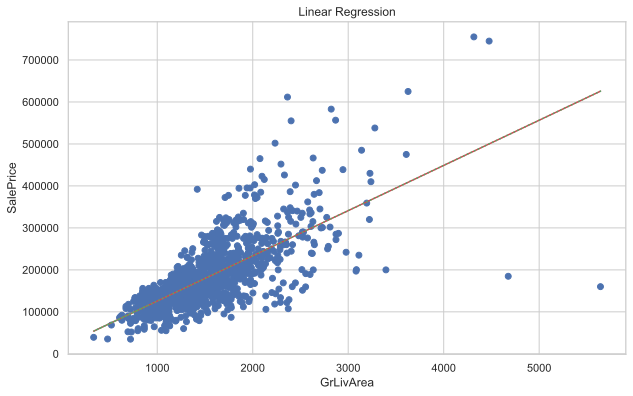

In [16]:
# create a figure
fig = plt.figure()
# get the axis of that figure
ax = plt.gca()

# plot a scatter plot on it with our data
ax.scatter(train.GrLivArea, train.SalePrice, c='b')
ax.plot(train['GrLivArea'], linear, color='r');
ax.plot(train['GrLivArea'], y_pred_linear, color='g',linestyle=':');
plt.title("Linear Regression")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice");

## Ridge

In [17]:
# A function that returns the cross-validation RMSE
# so we can evaluate our models and pick the best tuning parameter
def rmse_cv(model, X, Y):
    rmse = np.sqrt(-cross_val_score(model, X, Y, scoring="neg_mean_squared_error", cv = 5))
    return(rmse)

The main tuning parameter for the Ridge model is alpha - a regularization parameter that measures how flexible our model is. The higher the regularization the less prone our model will be to overfit. However it will also lose flexibility and might not capture all of the signal in the data.

\begin{equation*}
\Large{\sum_{i=1}^{M}\Bigg(y_i - \sum_{j=0}^p \beta_j x_{ij}\Bigg)^2 + \lambda \sum_{j=0}^p \beta_j^2}
\end{equation*}

In [18]:
alphas_ridge = [0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 50, 75]

In [19]:
cv_ridge_normal = [rmse_cv(Ridge(alpha = alpha), X_train_normal, y_train_normal).mean() 
            for alpha in alphas_ridge]

Text(0, 0.5, 'RMSE')

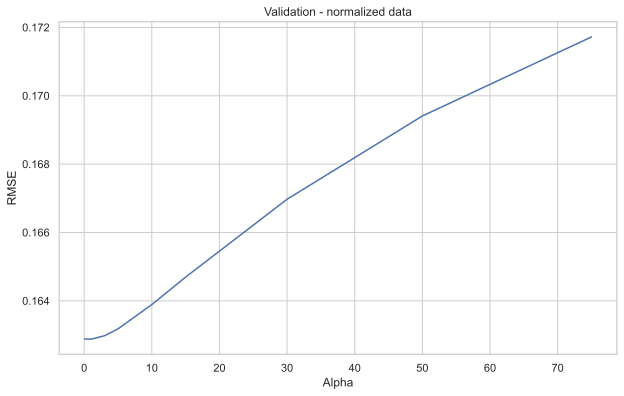

In [20]:
cv_ridge_normal = pd.Series(cv_ridge_normal, index = alphas_ridge)
cv_ridge_normal.plot(title = "Validation - normalized data")
plt.xlabel("Alpha")
plt.ylabel("RMSE")

When alpha is too large the regularization is too strong and the model cannot capture all the complexities in the data. If however we let the model be too flexible (alpha small) the model begins to overfit. 

In [21]:
cv_ridge = [rmse_cv(Ridge(alpha = alpha), X_train, y_train).mean() 
            for alpha in alphas_ridge]

In [22]:
cv_ridge = pd.Series(cv_ridge, index = alphas_ridge)

Text(0, 0.5, 'RMSE')

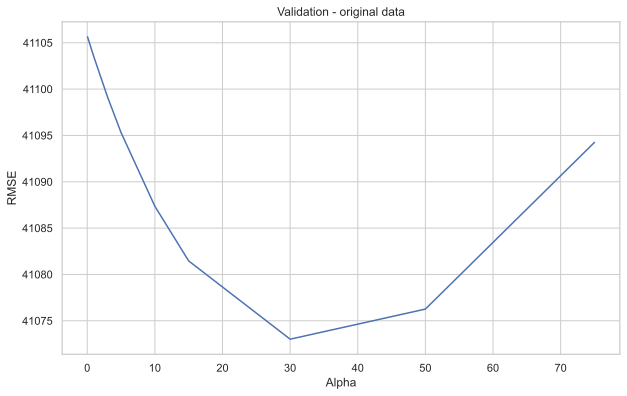

In [23]:
cv_ridge.plot(title = "Validation - original data")
plt.xlabel("Alpha")
plt.ylabel("RMSE")

In [24]:
print("RMSE WITHOUT normalization: " + str(cv_ridge.min()))
print("RMSE WITH normalization " + str(cv_ridge_normal.min()))

RMSE WITHOUT normalization: 41073.01608978592
RMSE WITH normalization 0.16287788640592762


#### Model training

In [25]:
model_ridge_normal = Ridge(1).fit(X_train_normal, y_train_normal)

In [26]:
model_ridge = Ridge(30).fit(X_train, y_train)

#### Predictions

In [27]:
y_pred_ridge_normal = model_ridge_normal.predict(X_test_normal)
y_pred_ridge = model_ridge.predict(X_test)

In [28]:
ridge_predictions_normal = np.expm1(y_pred_ridge_normal)

In [29]:
print("Ridge - normalized data RMSE: ", mean_squared_error(y_test, ridge_predictions_normal, squared=False))
print("Ridge RMSE: ", mean_squared_error(y_test, y_pred_ridge, squared=False))

Ridge - normalized data RMSE:  27728.551854294048
Ridge RMSE:  31136.126906564612


## Lasso

\begin{equation*}
\Large{\sum_{i=1}^{M}\Bigg(y_i - \sum_{j=0}^p \beta_j x_{ij}\Bigg)^2 + \lambda \sum_{j=0}^p |\beta_j|}
\end{equation*}

In [30]:
alphas_lasso1 = [1, 0.1, 0.05, 0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0004, 0.0006]
alphas_lasso2 = [1, 0.1]

#### Model training

In [31]:
model_lasso = LassoCV(alphas = alphas_lasso1).fit(X_train_normal.values, y_train_normal.values.ravel())

In [32]:
model_lasso.get_params()

{'alphas': [1,
  0.1,
  0.05,
  0.01,
  0.005,
  0.002,
  0.001,
  0.0005,
  0.0002,
  0.0004,
  0.0006],
 'copy_X': True,
 'cv': None,
 'eps': 0.001,
 'fit_intercept': True,
 'max_iter': 1000,
 'n_alphas': 100,
 'n_jobs': None,
 'positive': False,
 'precompute': 'auto',
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'verbose': False}

In [33]:
model_lasso.score(X_train_normal.values, y_train_normal.values.ravel())

0.83637347374086

In [34]:
model_lasso.alpha_

0.0002

In [35]:
model_lasso.cv

#### Feature selection

Another nice thing about the Lasso regression is that it does *feature selection* - setting unimportant features to zero.

![Lasso_Ridge](../data/img/Lasso_Ridge.png)

Let's look at the coefficients:

In [36]:
X_train

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd
Id,,,,,,,,,,
758,6,1386,2,440,672,672,2,6,1978,1978
599,5,1647,2,621,1430,1647,2,7,1977,1977
216,5,1236,1,447,1070,1236,1,6,1957,1996
136,7,1682,2,530,1304,1682,2,7,1970,1970
373,6,752,1,264,744,752,1,4,1984,1984
...,...,...,...,...,...,...,...,...,...,...
716,6,1350,2,478,1064,1350,2,7,1974,1974
906,5,1063,1,280,1056,1063,1,6,1954,1954
1097,6,1355,0,0,684,773,1,7,1914,2006


In [37]:
coef = pd.Series(model_lasso.coef_, index = X_train_normal.columns)

In [38]:
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef == 0)) + " variables")

Lasso picked 10 variables and eliminated the other 0 variables


We should take into acount that the features selected by Lasso are not necessarily the "corect" ones - especially if there are a lot of collinear features in the dataset.

Find out the most important coefficients:

In [39]:
imp_coef = pd.concat([coef.sort_values().head(5),
                     coef.sort_values().tail(5)])

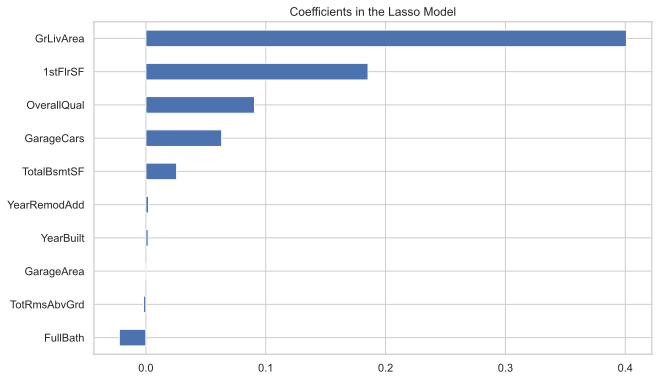

In [40]:
imp_coef.plot(kind = "barh")
plt.title("Coefficients in the Lasso Model");

In [41]:
imp_coef

FullBath       -0.022186
TotRmsAbvGrd   -0.001965
GarageArea      0.000033
YearBuilt       0.001897
YearRemodAdd    0.002216
TotalBsmtSF     0.025678
GarageCars      0.063246
OverallQual     0.090632
1stFlrSF        0.185367
GrLivArea       0.400964
dtype: float64

The most important positive feature is `GrLivArea` - the above ground area in square feet.

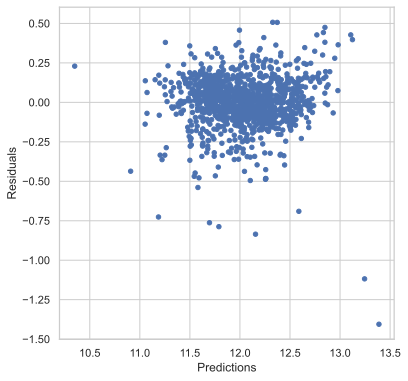

In [42]:
# let's look at the residuals on the train dataset as well:

fig, ax = plt.subplots(figsize=(6,6))
preds = pd.DataFrame({"Predictions": model_lasso.predict(X_train_normal.values), "true": y_train_normal.values.ravel()})
preds["Residuals"] = preds["true"] - preds["Predictions"]
preds.plot(x = "Predictions", y = "Residuals", kind = "scatter", ax=ax);

#### Predictions

In [43]:
y_pred_lasso_normal = model_lasso.predict(X_test_normal.values)

In [44]:
lasso_predictions_normal = np.expm1(y_pred_lasso_normal)

In [45]:
print("Ridge RMSE: ", mean_squared_error(y_test, ridge_predictions_normal, squared=False))
print("Lasso RMSE: ", mean_squared_error(y_test, lasso_predictions_normal, squared=False))

Ridge RMSE:  27728.551854294048
Lasso RMSE:  27721.44106250882


# 4. Hands on
By using the same approach, fit and evaluate an Elastic Net model on the normalized data with cross-validation.

Set CV to 3 folds, and use the prepaired fields for alpha values and l1_ratio.
For more details on Elastic Net model, check the [Elastic Net CV scikit-learn documentation](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.ElasticNetCV.html#sklearn.linear_model.ElasticNetCV).

## 1. Create/Build model - Regression

In [72]:
alphas_elnet = [1, 0.1, 0.05, 0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0004, 0.0006]
l1_ratio_elnet = [.1, .5, .7, .9, .95, .99, 1]

In [73]:
# model_elnet = ElasticNetCV()
model_elnet = ElasticNetCV(cv=3, random_state=100, alphas=alphas_elnet, l1_ratio=l1_ratio_elnet)

## 2. Fit model
Train the model.

In [74]:
# model_elnet.fit()
model_elnet.fit(X_train_normal.values, y_train_normal.values.ravel())

ElasticNetCV(alphas=[1, 0.1, 0.05, 0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002,
                     0.0004, 0.0006],
             cv=3, l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1],
             random_state=100)

## 3. Evaluate the model
Make predictions for the test dataset and get some evaluation measurements.

In [75]:
# y_pred_elnet_normal = model_elnet.predict()
y_pred_elnet_normal = model_elnet.predict(X_test_normal.values)

In [76]:
y_pred_elnet_normal = np.expm1(y_pred_elnet_normal)
print("Elastic Net RMSE: ", mean_squared_error(y_test, y_pred_elnet_normal, squared=False))

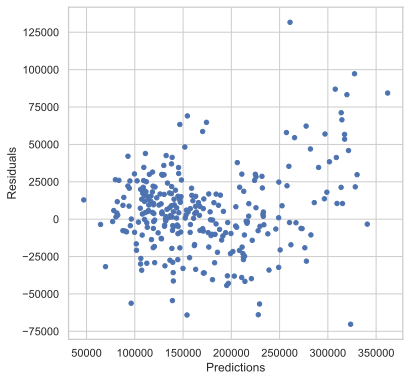

In [79]:
fig, ax = plt.subplots(figsize=(6,6))
preds = pd.DataFrame({"Predictions": y_pred_elnet_normal, "true": y_test.values.ravel()})
preds["Residuals"] = preds["true"] - preds["Predictions"]
preds.plot(x = "Predictions", y = "Residuals", kind = "scatter", ax=ax);



_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - basic_  
_Notebook: 2b_Regression_House_prices_  
_Instructors: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_  
_Intended user: XY_  
_Date: 1st January 1991_  

_References:_
- _Ames Housing Dataset (hosted on Kaggle): https://www.kaggle.com/datasets/prevek18/ames-housing-dataset_
- _Scikit-learn Linear Models: https://scikit-learn.org/1.5/modules/linear_model.html_
- _Scikit-learn LinearRegression: https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression_
- _Scikit-learn LassoCV: https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LassoCV.html_
- _Scikit-learn RidgeCV: https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.RidgeCV.html#sklearn.linear_model.RidgeCV_
- _Scikit-learn ElasticNetCV: https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.ElasticNetCV.html_

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_

